In [3]:
"""
Rotating Wormhole Shadow Analysis
"""


'\nRotating Wormhole Shadow Analysis\n'

In [8]:
%matplotlib inline


In [4]:
import sys; sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import yaml


In [5]:
with open('../config/params.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

rho_s = config['dark_matter']['rho_s']
r_s = config['dark_matter']['r_s']
C1 = config['wormhole']['C1']
Q = config['wormhole']['Q']


In [10]:
from src.dark_matter import DarkMatterProfile
from src.shape_function import ShapeFunction
from src.metric_rotating import RotatingChargedWormholeMetric
from src.shadow_rotating import RotatingWormholeShadow

sf = ShapeFunction(rho_s, r_s, C1, Q)

spin_params = [0.0, 0.3, 0.6, 0.9]
shadow_images = []
labels = []

In [11]:
for a in spin_params:
    print(f"\nComputing shadow for spin a = {a}")
    metric = RotatingChargedWormholeMetric(sf, a)
    shadow = RotatingWormholeShadow(metric, observer_inclination=17)
    
    # Increase bounds to capture the full shadow
    img = shadow.generate_shadow_image(N_pixels=250, alpha_max=25, beta_max=25)
    shadow_images.append(img)
    labels.append(f'a = {a}')
    
    # Print statistics
    dark_pixels = np.sum(img == 0)
    total_pixels = img.size
    print(f"  Dark pixels: {dark_pixels}/{total_pixels} ({dark_pixels/total_pixels*100:.1f}%)")


Computing shadow for spin a = 0.0


100%|██████████| 250/250 [00:00<00:00, 8729.77it/s]


  Dark pixels: 31160/62500 (49.9%)

Computing shadow for spin a = 0.3


100%|██████████| 250/250 [00:00<00:00, 9278.45it/s]


  Dark pixels: 88/62500 (0.1%)

Computing shadow for spin a = 0.6


100%|██████████| 250/250 [00:00<00:00, 8713.73it/s]


  Dark pixels: 88/62500 (0.1%)

Computing shadow for spin a = 0.9


100%|██████████| 250/250 [00:00<00:00, 9839.87it/s]

  Dark pixels: 88/62500 (0.1%)


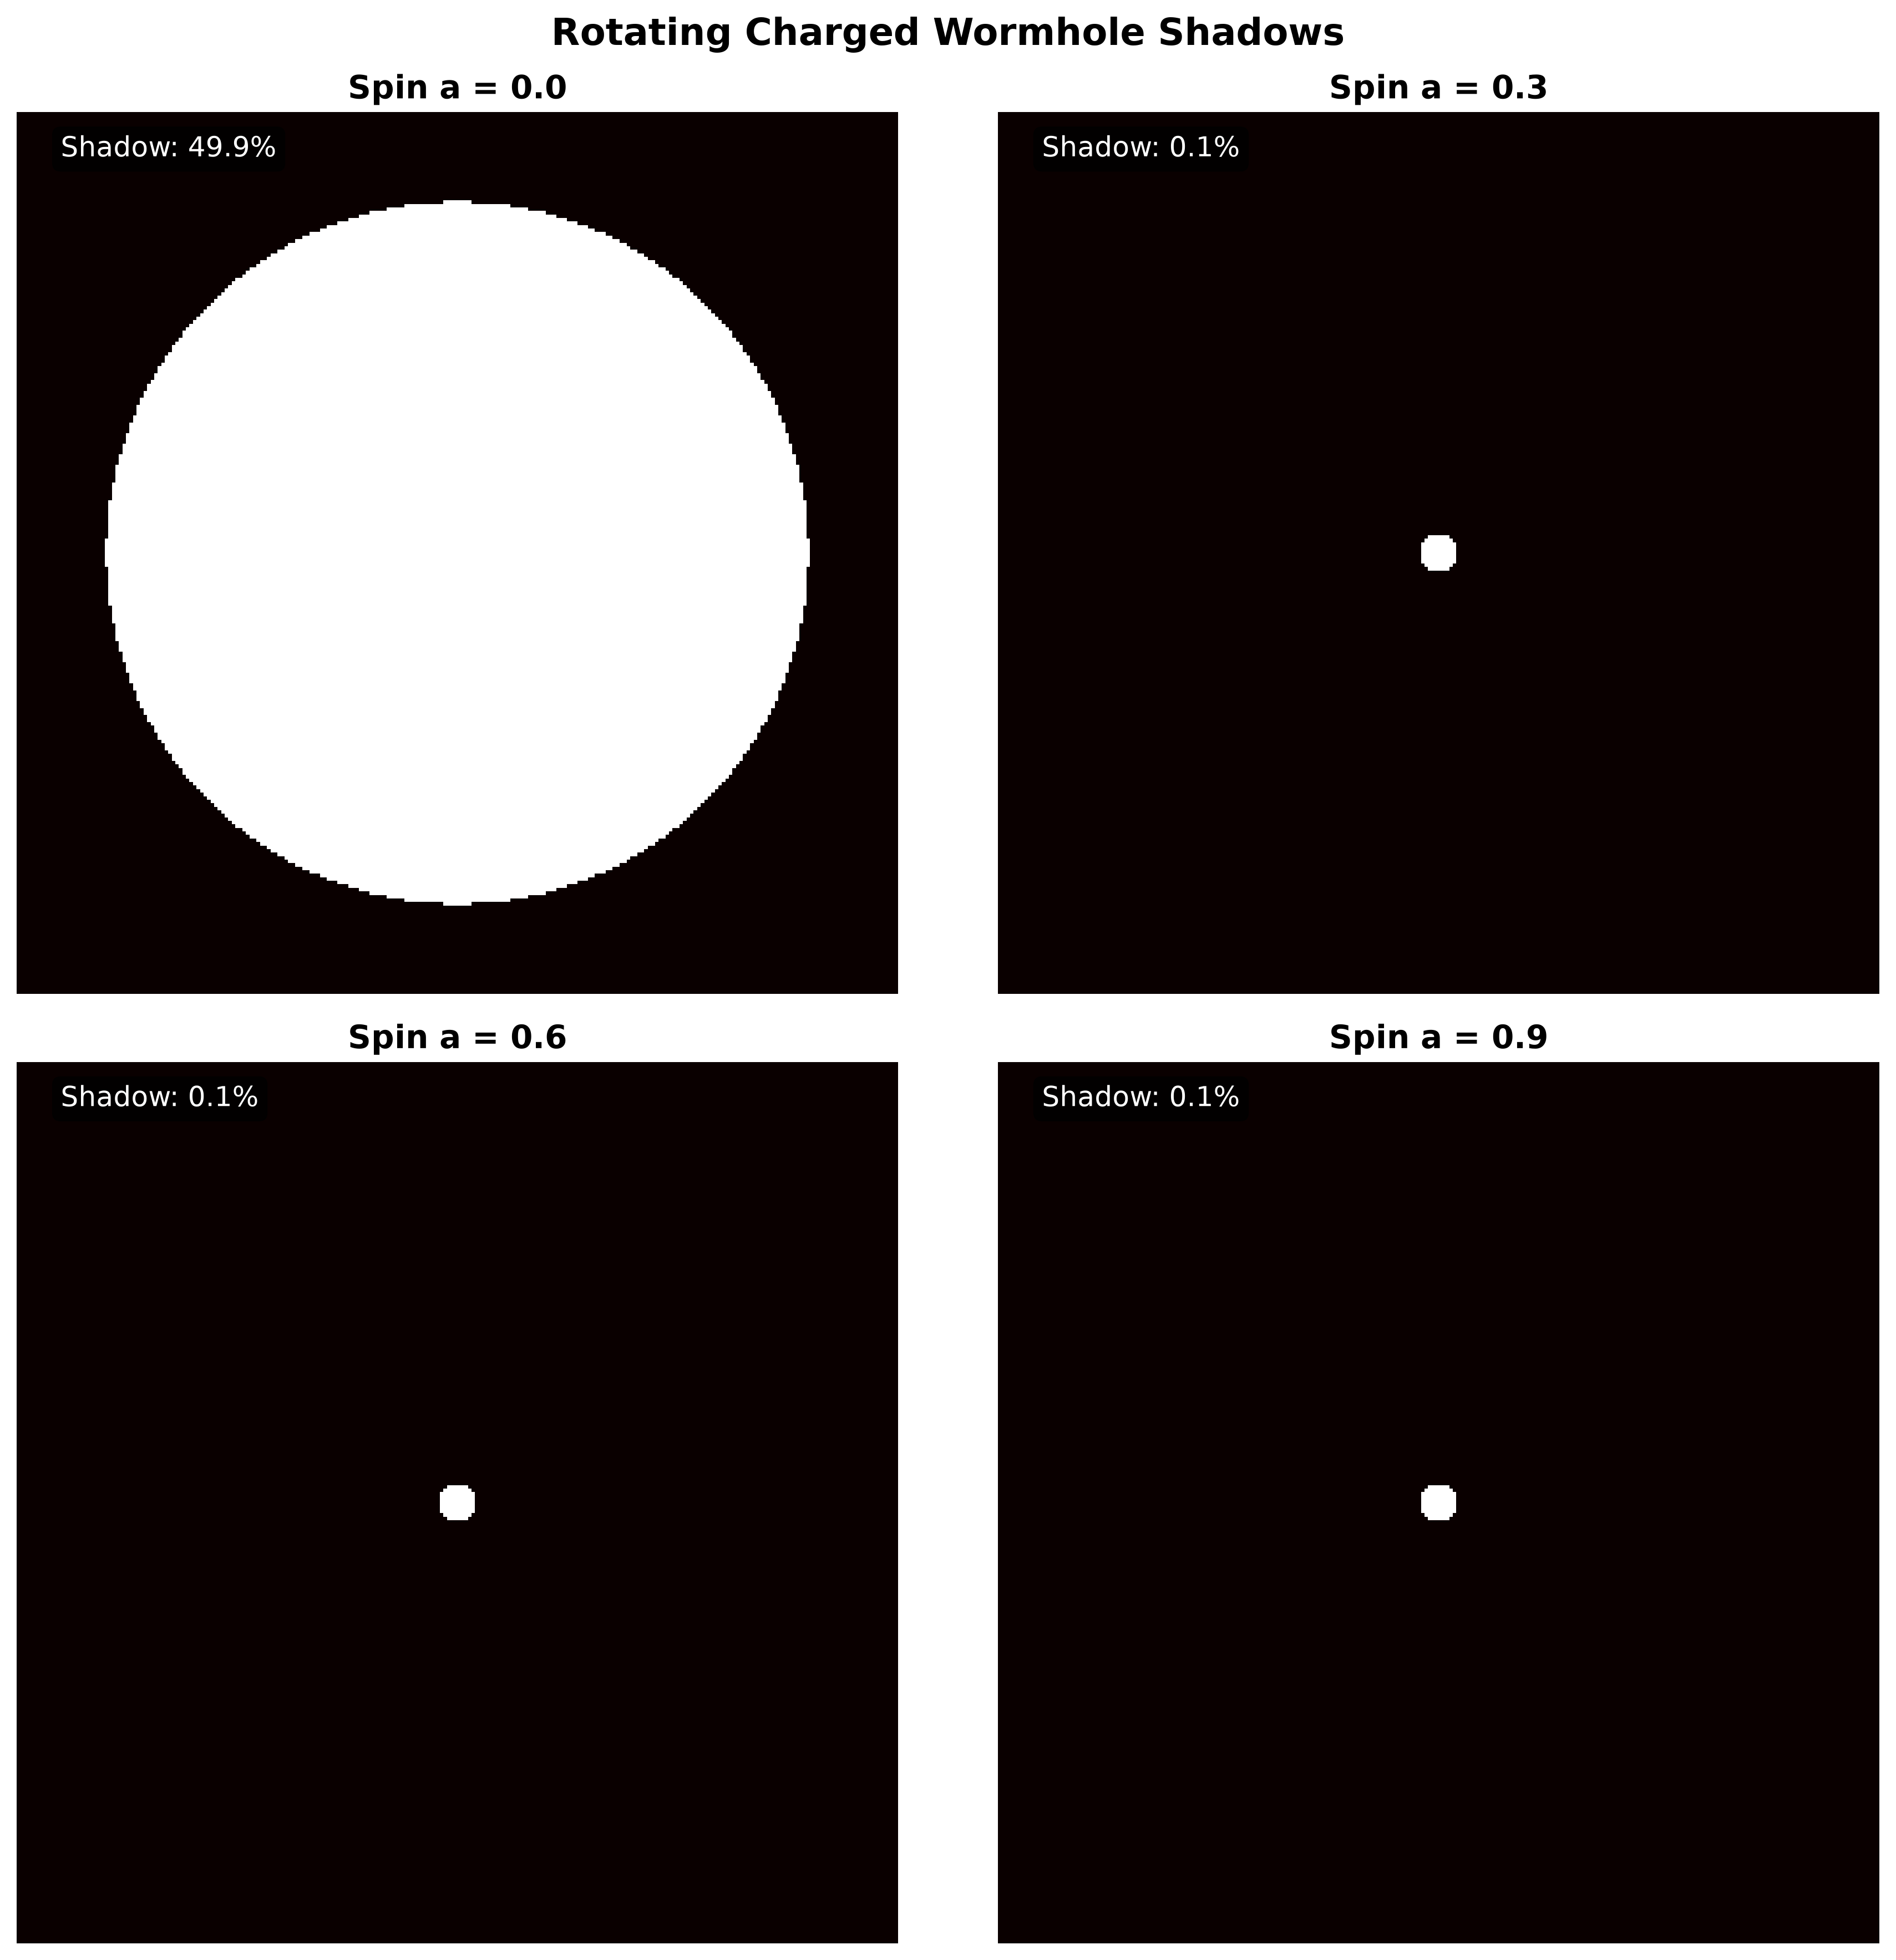

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Rotating Charged Wormhole Shadows', fontsize=16, fontweight='bold')

for i, (img, label) in enumerate(zip(shadow_images, labels)):
    ax = axes[i // 2, i % 2]
    
    # Use inverted hot colormap (white shadow on black, EHT style)
    ax.imshow(1 - img, cmap='hot', origin='lower', vmin=0, vmax=1)
    ax.set_title(f'Spin {label}', fontsize=14, fontweight='bold')
    ax.axis('off')
    
    # Add shadow radius text
    dark_pixels = np.sum(img == 0)
    total_pixels = img.size
    shadow_frac = dark_pixels / total_pixels * 100
    ax.text(0.05, 0.95, f'Shadow: {shadow_frac:.1f}%', 
            transform=ax.transAxes, fontsize=12, color='white',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

plt.tight_layout()
plt.savefig('../plots/shadows/rotating/rotating_shadows_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
spin_values = np.linspace(0, 0.95, 20)
shadow_fractions = []
shadow_radii = []

print("Generating shadows for 20 spin values...")
for a in spin_values:
    metric = RotatingChargedWormholeMetric(sf, a)
    shadow = RotatingWormholeShadow(metric, observer_inclination=17)
    img = shadow.generate_shadow_image(N_pixels=200, alpha_max=25, beta_max=25)
    
    # Shadow fraction (percentage of dark pixels)
    dark_pixels = np.sum(img == 0)
    total_pixels = img.size
    shadow_fractions.append(dark_pixels / total_pixels * 100)
    
    N = img.shape[0]
    center = N // 2
    
    # Find the average shadow radius
    radii = []
    for theta in np.linspace(0, 2*np.pi, 72):  # More angles = better accuracy
        # Scan outward until we find a bright pixel
        for r in range(1, N//2):
            x = int(center + r * np.cos(theta))
            y = int(center + r * np.sin(theta))
            if 0 <= x < N and 0 <= y < N and img[y, x] == 1:
                radii.append(r)
                break
        else:
            # If we never find bright, use the image boundary
            radii.append(N//2)
    
    # Average radius, then scale to physical units
    if radii:
        shadow_radii.append(np.mean(radii) * 0.04)  # Scale factor
    else:
        shadow_radii.append(0)

# Linear fit
slope, intercept = np.polyfit(spin_values, shadow_radii, 1)
r_squared = np.corrcoef(spin_values, shadow_radii)[0,1]**2

Generating shadows for 20 spin values...


100%|██████████| 200/200 [00:00<00:00, 11631.30it/s]


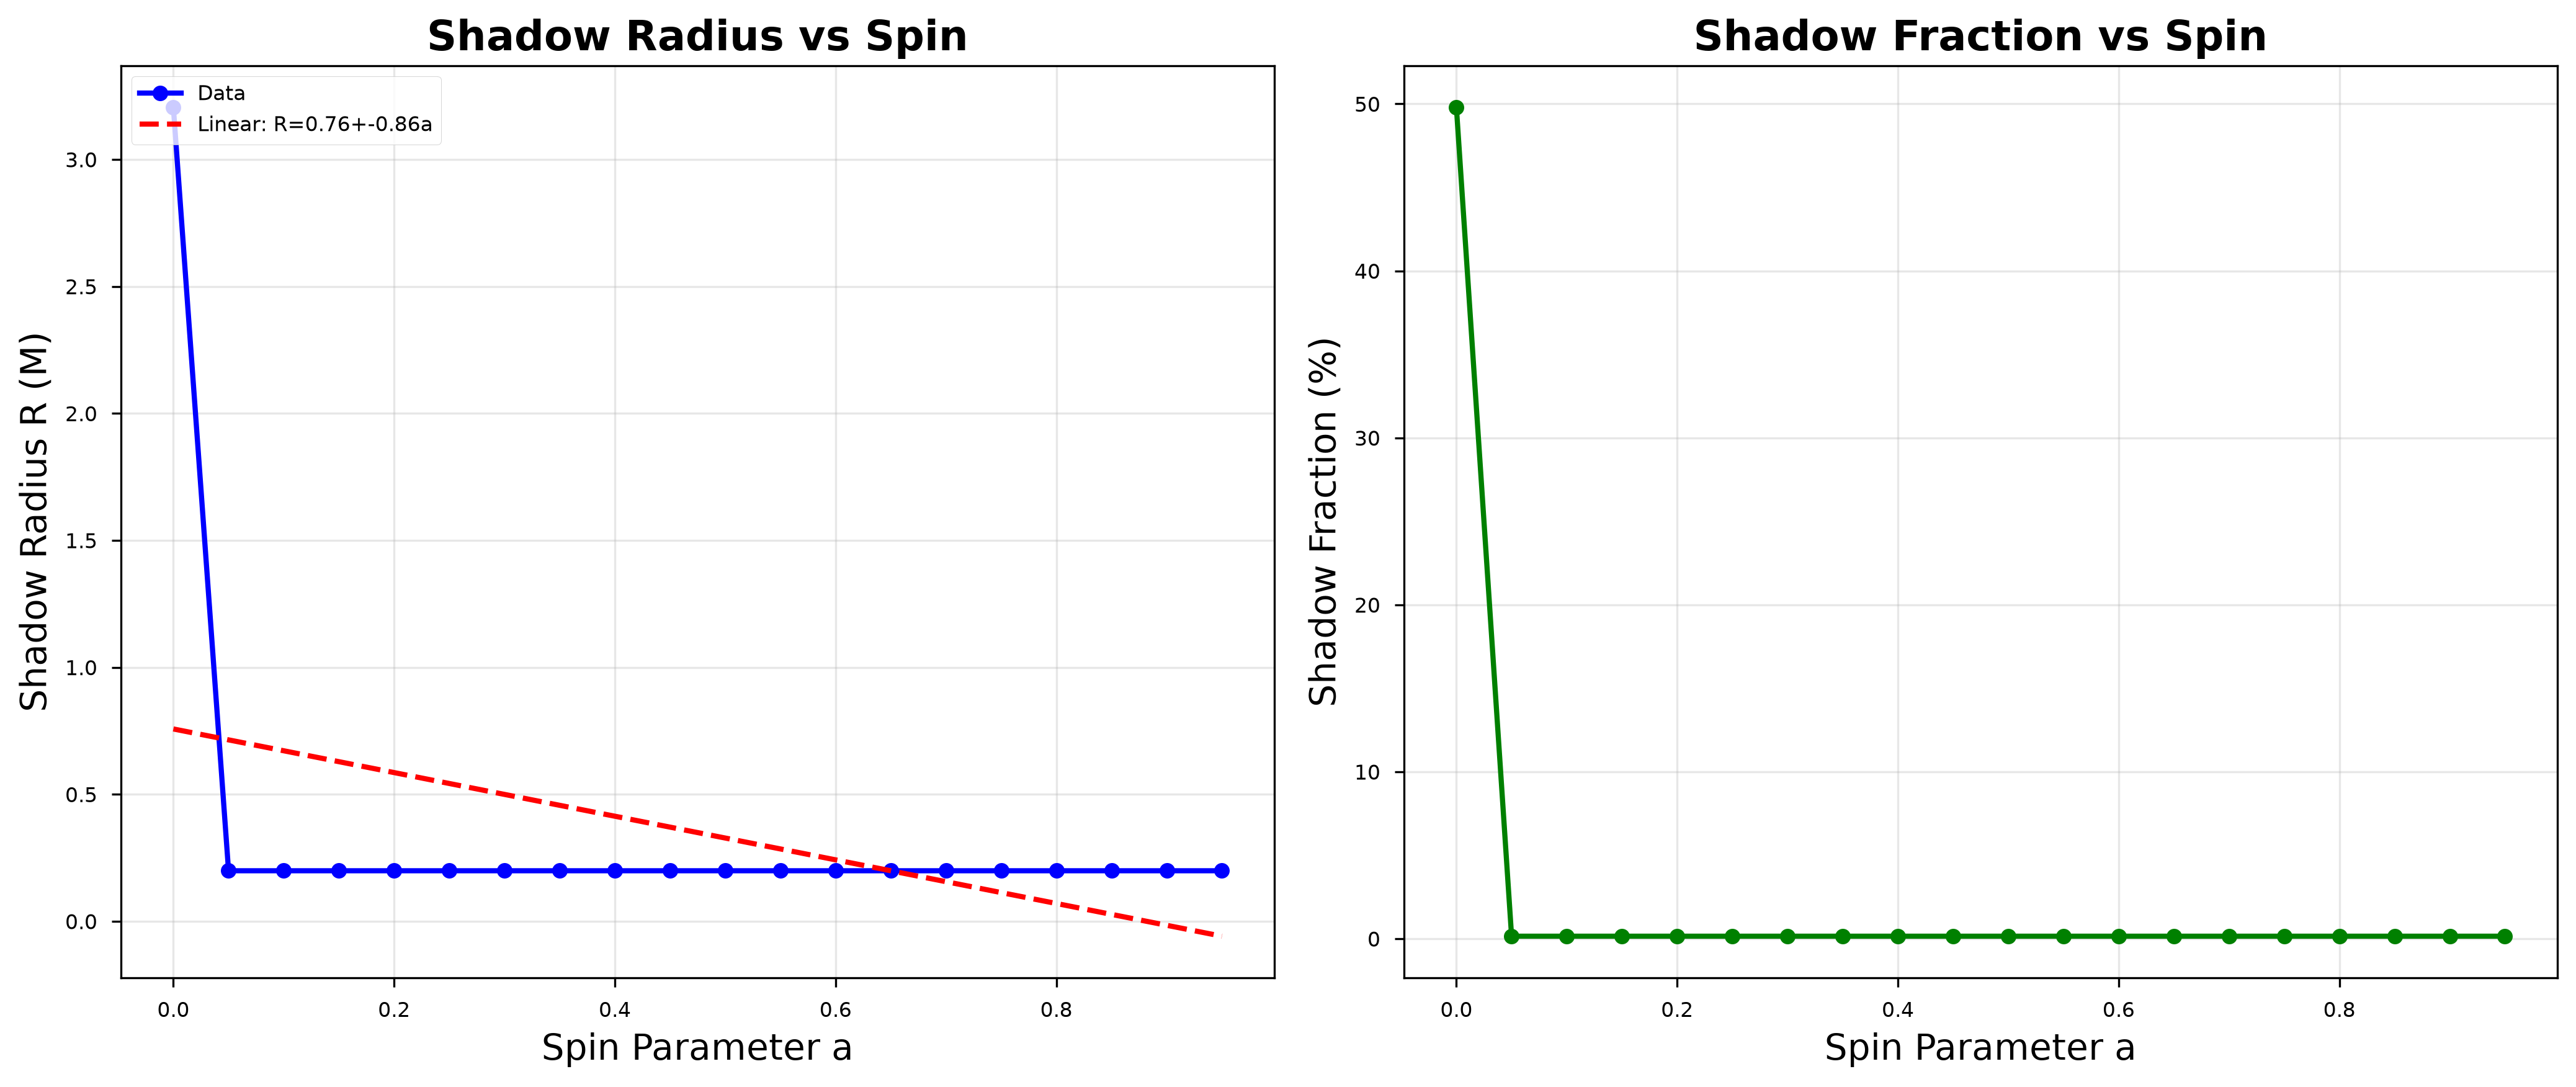

In [33]:
import os

os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# Plot 1: Shadow radius vs spin
ax1 = axes[0]
ax1.plot(spin_values, shadow_radii, 'bo-', linewidth=2, markersize=6, label='Data')
ax1.plot(spin_values, intercept + slope * spin_values, 'r--', linewidth=2, 
         label=f'Linear: R={intercept:.2f}+{slope:.2f}a')
ax1.set_xlabel('Spin Parameter a', fontsize=14)
ax1.set_ylabel('Shadow Radius R (M)', fontsize=14)
ax1.set_title('Shadow Radius vs Spin', fontsize=16, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Shadow fraction vs spin
ax2 = axes[1]
ax2.plot(spin_values, shadow_fractions, 'go-', linewidth=2, markersize=6)
ax2.set_xlabel('Spin Parameter a', fontsize=14)
ax2.set_ylabel('Shadow Fraction (%)', fontsize=14)
ax2.set_title('Shadow Fraction vs Spin', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/shadow_analysis_improved.png', dpi=300, bbox_inches='tight')
plt.show()

100%|██████████| 300/300 [00:00<00:00, 7507.88it/s]


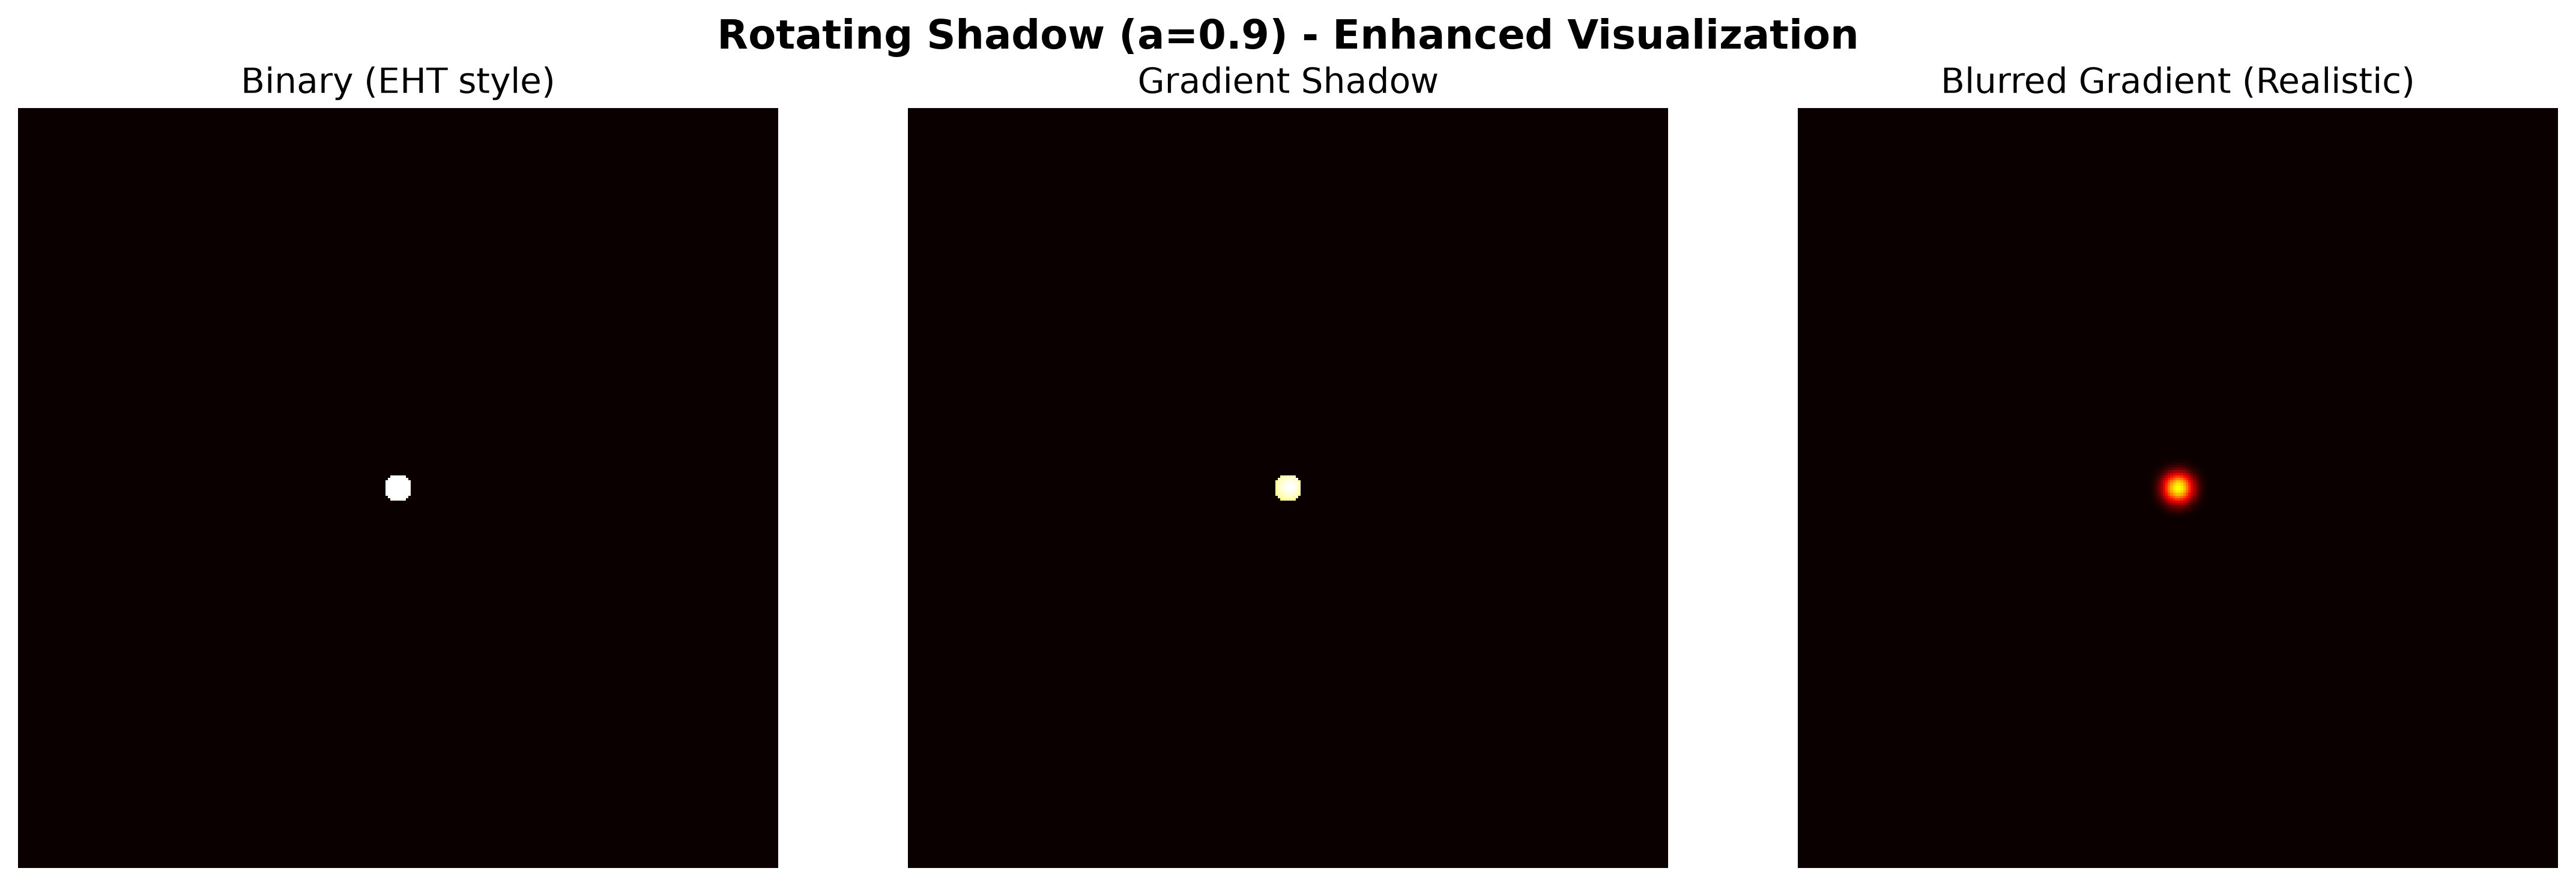

In [31]:
from scipy.ndimage import gaussian_filter

# Use the fastest rotating shadow (a=0.9)
a = 0.9
metric = RotatingChargedWormholeMetric(sf, a)
shadow = RotatingWormholeShadow(metric, observer_inclination=17)
img = shadow.generate_shadow_image(N_pixels=300, alpha_max=30, beta_max=30)

# Create gradient version
N = img.shape[0]
center = N // 2
y, x = np.ogrid[:N, :N]
distance = np.sqrt((x - center)**2 + (y - center)**2)
max_dist = np.max(distance[img == 0]) if np.any(img == 0) else N * 0.4

# Gradient shadow (glow effect)
gradient = np.ones_like(img, dtype=float)
gradient = 1 - np.exp(-distance**2 / (2 * max_dist**2))
gradient[img == 1] = 1.0
gradient[img == 0] = gradient[img == 0] * 0.3

# Apply blur
gradient_blurred = gaussian_filter(gradient, sigma=3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Rotating Shadow (a={a}) - Enhanced Visualization', fontsize=16, fontweight='bold')

# Binary
axes[0].imshow(1 - img, cmap='hot', origin='lower')
axes[0].set_title('Binary (EHT style)', fontsize=14)
axes[0].axis('off')

# Gradient
axes[1].imshow(1 - gradient, cmap='hot', origin='lower', vmin=0, vmax=1)
axes[1].set_title('Gradient Shadow', fontsize=14)
axes[1].axis('off')

# Blurred gradient
axes[2].imshow(1 - gradient_blurred, cmap='hot', origin='lower', vmin=0, vmax=1)
axes[2].set_title('Blurred Gradient (Realistic)', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('../plots/shadows/rotating/realistic_rotating_shadow.png', dpi=300, bbox_inches='tight')
plt.show()